---
---
# TP d'un modèle de diffusion
---
---

# Création de l'environnement virtuel

In [47]:
%pip install -r requirements.txt

ERROR: Could not find a version that satisfies the requirement copy (from versions: none)

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
ERROR: No matching distribution found for copy
Note: you may need to restart the kernel to use updated packages.


# Import des packages

In [48]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import numpy as np
from copy import deepcopy

---

# Partie I : Fondements Théoriques

---

## 1. Pourquoi modéliser la diffusion par une SDE ?

### Le problème de la génération

On dispose d'un dataset $\{\mathbf{x}_0^{(i)}\}_{i=1}^N$ tiré d'une distribution inconnue $p_{\text{data}}(\mathbf{x})$. Notre objectif est de **générer de nouveaux échantillons** qui suivent cette distribution.

### L'idée centrale : transformer le bruit en données

L'intuition est de construire un **pont** entre deux distributions :
- La distribution des données $p_{\text{data}}$ (complexe, inconnue)
- Une gaussienne standard $\mathcal{N}(\mathbf{0}, \mathbf{I})$ (simple, facile à échantillonner)

### Pourquoi une SDE (Stochastic Differential Equation) ?

Une **SDE** est l'outil naturel pour modéliser ce processus car :

1. **Caractère continu** : Elle décrit l'évolution continue d'une variable aléatoire au cours du temps
2. **Théorème d'Anderson (1982)** : Toute SDE de diffusion admet une **SDE reverse** qui permet de remonter le temps
3. **Flexibilité** : On peut choisir différents schémas de bruit (VE, VP, etc.)

La forme générale de notre SDE forward est :

$$
\boxed{d\mathbf{x} = \mathbf{f}(\mathbf{x}, t)\, dt + g(t)\, d\mathbf{w}}
$$

où :
- $\mathbf{f}(\mathbf{x}, t)$ est le **drift** (terme déterministe)
- $g(t)$ est le **coefficient de diffusion** (intensité du bruit)
- $d\mathbf{w}$ est un **mouvement brownien standard**

### Analogie physique

Imaginez une goutte d'encre dans l'eau :
- Au début ($t=0$) : l'encre est concentrée (notre distribution de données)
- Avec le temps : elle diffuse progressivement
- À $t=T$ : elle est uniformément répartie (bruit gaussien)

Les modèles de diffusion apprennent à **inverser ce processus** : partir de l'eau trouble pour reconstituer la goutte d'encre !

## 2. Trois discrétisations : VE, VP-OU, DDPM

La SDE continue doit être **discrétisée** pour l'implémentation. Il existe trois familles principales :

### 2.1 Variance Exploding (VE-SDE)

**Idée :** On ajoute du bruit sans atténuer le signal. En prenant : $f=0$ et $g(t) = \sqrt{\frac{d[\sigma^2(t)]}{dt}}$

$$
d\mathbf{x} = \sqrt{\frac{d[\sigma^2(t)]}{dt}}\, d\mathbf{w}
$$

**Discrétisation :**
$$
\mathbf{x}_t = \mathbf{x}_0 + \sigma_t\, \boldsymbol{\epsilon}
$$

- C'est simple à implémenter
- MAIS :a variance explose ($\sigma_T \gg 1$)

### 2.2 Variance Preserving - Ornstein-Uhlenbeck (VP-OU)

**Idée :** On atténue le signal tout en ajoutant du bruit, de sorte que la variance totale reste constante. En prenant : $f(x,t) = -x_t$ et $g(t) \sqrt{2}$

$$
d\mathbf{x} = -x_t dt + \sqrt{2}\, d\mathbf{w}
$$

**Discrétisation :**
$$
\mathbf{x}_t = \exp(-t)\mathbf{x}_0 + \sqrt{1 - \exp(-2t)}\boldsymbol{\epsilon}
$$
- La variance bornée
- MAIS pour obtenir que du bruit il faut avoir $t= \infty$

### 2.3 DDPM (Denoising Diffusion Probabilistic Model)

**Idée :** C'est une discrétistation plus général de VP-OU, en définissant la chaine de Markov suivante : 
$$
\mathbf{x}_{t} = \sqrt{\beta_t}\mathbf{x}_{t-1} + \sqrt{1-\beta_t}\boldsymbol{\epsilon}
$$
Par récurence immédiate, on obtient l'équation DDPM suivante : 
$$
\boxed{\mathbf{x}_t = \sqrt{\bar{\alpha}_t}\, \mathbf{x}_0 + \sqrt{1 - \bar{\alpha}_t}\, \boldsymbol{\epsilon}}
$$

où $\bar{\alpha}_t = \prod_{s=1}^t (1 - \beta_s) = \prod_{s=1}^t \alpha_s$.

- Bruitage plus efficace
- Équivalent mathématique à VP-OU

**ET C'est ce qu'on va implémenter !**

### Tableau comparatif

| Méthode | Drift $f(x,t)$ | Diffusion $g(t)$ | Formule directe |
|---------|----------------|------------------|------------------|
| **VE** | $0$ | $\sqrt{\frac{d[\sigma^2(t)]}{dt}}$ | $x_t = x_0 + \sigma_t \epsilon$ |
| **VP-OU** | $-x_t$ | $\sqrt{2}$ | $\mathbf{x}_t = \exp(-t)\mathbf{x}_0 + \sqrt{1 - \exp(-2t)}\boldsymbol{\epsilon}$ |
| **DDPM** | $\sqrt{\bar{\alpha}_t}$ | $\sqrt{1-\bar{\alpha}_t}$ | $x_t = \sqrt{\bar{\alpha}_t}x_0 + \sqrt{1-\bar{\alpha}_t}\epsilon$ |

# 3. Implémentation

## 3.1 Noise scheduler linéaire
Ici on implémente :

1 - $\beta_s$ linéaire (avec $\beta_0 = 0$)

2- $\bar{\alpha}_t$ avec :  $\bar{\alpha}_t = \prod_{s=1}^t (1 - \beta_s) = \prod_{s=1}^t \alpha_s$.

---
---
**Questions** : 

1 - Si $t=0$ que devient l'équation : $\boxed{\mathbf{x}_t = \sqrt{\bar{\alpha}_t}\, \mathbf{x}_0 + \sqrt{1 - \bar{\alpha}_t}\, \boldsymbol{\epsilon}}$ ? 

2 - Si $t$ grand que devient l'équation : $\boxed{\mathbf{x}_t = \sqrt{\bar{\alpha}_t}\, \mathbf{x}_0 + \sqrt{1 - \bar{\alpha}_t}\, \boldsymbol{\epsilon}}$ ? 

3 - Qu'est ce que cela veut dire d'un point de vue de l'image $x_t$ ?

---
---

In [49]:
T = 1000           # nombre de pas de diffusion
beta_start = 1e-4  # beta_0
beta_end = 0.02    # beta_T

# --- Noise schedule lineaire (le beta) ---
betas = torch.linspace(beta_start, beta_end, T)  # linspace --> répartition linéaire des bétas

# --- alphas ---
alphas = 1.0 - betas                              # alpha_t = 1 - beta_t
alphas_bar = torch.cumprod(alphas, dim=0)          # alpha_bar_t = prod_{s=1}^{t} alpha_s

# --- Verification ---
print(f"betas       : min={betas[0]:.6f}, max={betas[-1]:.6f}, shape={betas.shape}")
print(f"alphas_bar  : alpha_bar_1={alphas_bar[0]:.6f}, alpha_bar_T={alphas_bar[-1]:.6f}")
print(f"SNR a t=T   : sqrt(alpha_bar_T)={alphas_bar[-1].sqrt():.4f}, sqrt(1-alpha_bar_T)={((1-alphas_bar[-1]).sqrt()):.4f}")

betas       : min=0.000100, max=0.020000, shape=torch.Size([1000])
alphas_bar  : alpha_bar_1=0.999900, alpha_bar_T=0.000040
SNR a t=T   : sqrt(alpha_bar_T)=0.0064, sqrt(1-alpha_bar_T)=1.0000


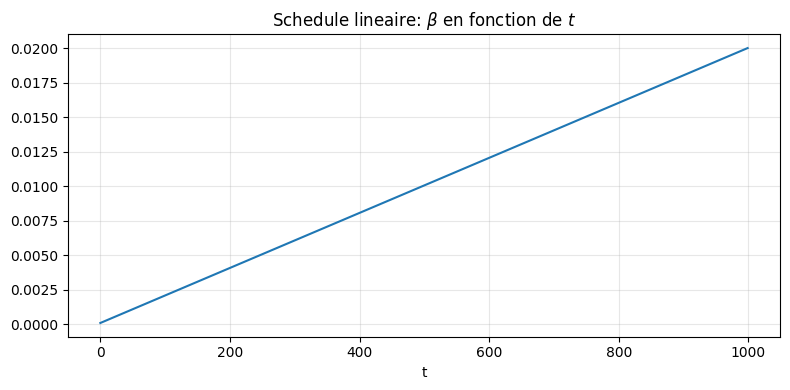

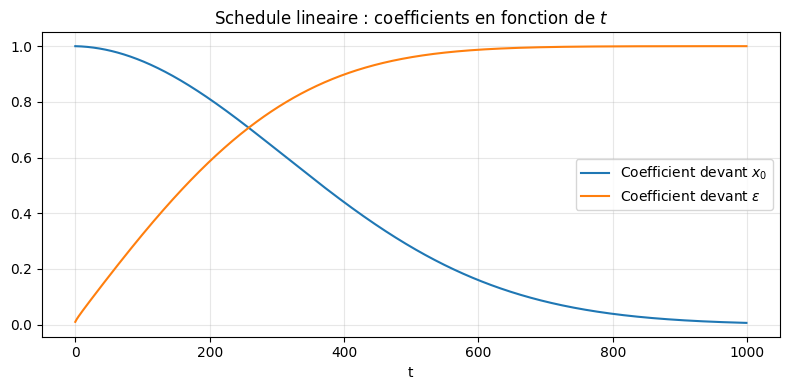

In [50]:
plt.figure(figsize=(8, 4))
plt.plot(range(T), betas)
plt.xlabel("t")
plt.title(r"Schedule lineaire: $\beta$ en fonction de $t$")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(range(T), np.sqrt(alphas_bar.numpy()), label =r"Coefficient devant $x_0$")
plt.plot(range(T), np.sqrt(1-alphas_bar.numpy()), label =r"Coefficient devant $\varepsilon$")
plt.xlabel("t")
plt.legend()
plt.title(r"Schedule lineaire : coefficients en fonction de $t$")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3.2 Processus forward
Ici on implémente : $\boxed{\mathbf{x}_t = \sqrt{\bar{\alpha}_t}\, \mathbf{x}_0 + \sqrt{1 - \bar{\alpha}_t}\, \boldsymbol{\epsilon}}$.

In [51]:
def forward_diffusion(x_0, t, alphas_bar):
    """
    Applique le forward process : x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1 - alpha_bar_t) * epsilon

    Args:
        x_0: image propre, shape (B, C, H, W)
        t: timesteps, shape (B,) avec valeurs dans [0, T-1]
        alphas_bar: alpha_bar precalcules, shape (T,)

    Returns:
        x_t: image bruitee, shape (B, C, H, W)
        epsilon: le bruit ajoute, shape (B, C, H, W)
    """
    # Recuperer alpha_bar_t pour chaque element du batch
    alpha_bar_t = alphas_bar[t]  # (B,)

    # Reshape  (B,) -> (B, 1, 1, 1)
    alpha_bar_t = alpha_bar_t.view(-1, 1, 1, 1)

    # Echantillonner le bruit
    epsilon = torch.randn_like(x_0)

    # Formule DDPM
    x_t = torch.sqrt(alpha_bar_t) * x_0 + torch.sqrt(1.0 - alpha_bar_t) * epsilon

    return x_t, epsilon

Ici on regarde le processus forward sur une image au cours du temps sur des images de visages.

x_0 shape: torch.Size([1, 3, 256, 256]), min=0.00, max=0.91


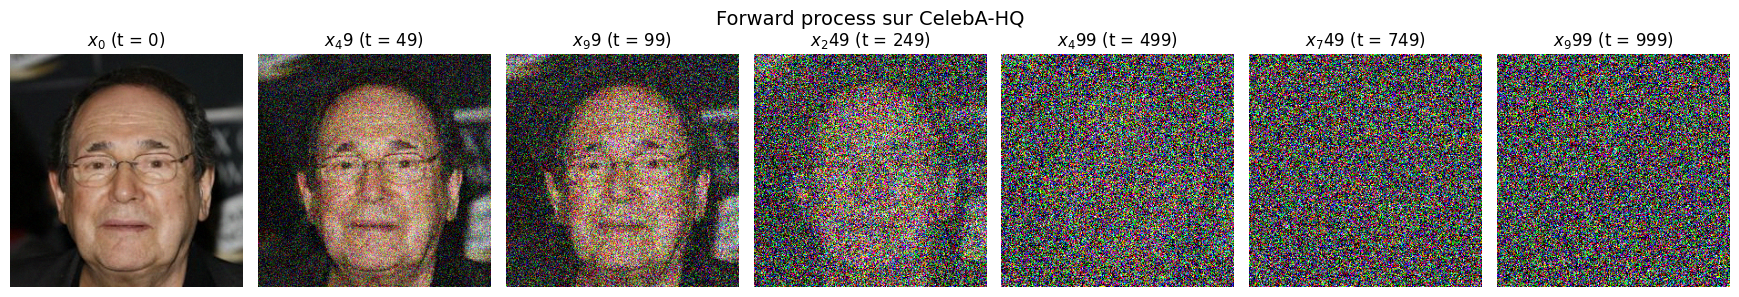

In [52]:
from PIL import Image
from torchvision import transforms

# --- Charger une image CelebA-HQ ---
img_pil = Image.open("celeba_hq_256/00001.jpg")

transform = transforms.Compose([
    transforms.ToTensor(),  # [0, 255] -> [0, 1], shape (C, H, W)

])

x_0 = transform(img_pil).unsqueeze(0)  # (1, 3, 256, 256)
print(f"x_0 shape: {x_0.shape}, min={x_0.min():.2f}, max={x_0.max():.2f}")

# --- Visualisation du forward process ---
timesteps = [0, 49, 99, 249, 499, 749, 999]

fig, axes = plt.subplots(1, len(timesteps), figsize=(2.5 * len(timesteps), 3))

for i, t_val in enumerate(timesteps):
    t = torch.tensor([t_val])
    x_t, _ = forward_diffusion(x_0, t, alphas_bar)

    img = x_t[0].permute(1, 2, 0).clamp(0, 1).numpy()
    axes[i].imshow(img)
    axes[i].set_title(f"$x_{t_val}$ (t = {t_val})")
    axes[i].axis("off")

fig.suptitle("Forward process sur CelebA-HQ", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Reverse Process (Denoising / Generation)

### 4.1. Le problème

On veut partir d'un bruit et faire le chemin inverse pour générer une image. Ainsi, on veut échantillonner $q(\mathbf{x}_{t-1} | \mathbf{x}_t)$, mais cette distribution est **intractable** (non calculable simplement) car elle dépend de la distribution entière des données $q(\mathbf{x}_0)$ qu'on ne connaît pas.

### 4.2. Formule de Tweedie : relier le score au bruit

On part de l'équation du forward process DDPM :

$$\mathbf{x}_t = \sqrt{\bar{\alpha}_t}\,\mathbf{x}_0 + \sqrt{1-\bar{\alpha}_t}\,\boldsymbol{\epsilon}, \quad \boldsymbol{\epsilon} \sim \mathcal{N}(0, \mathbf{I})$$

La formule de Tweedie relie l'estimateur optimal de $\mathbf{x}_0$ au **score marginal** $\nabla_{\mathbf{x}_t} \log q_t(\mathbf{x}_t)$ (le gradient du log de la densité marginale à l'instant $t$) :

$$\mathbb{E}[\mathbf{X}_0 | \mathbf{X}_t] = \frac{1}{\sqrt{\bar{\alpha}_t}} \Big( \mathbf{X}_t + (1 - \bar{\alpha}_t)\, \nabla_{\mathbf{X}_t} \log q_t(\mathbf{X}_t) \Big)$$

En réarrangeant et en utilisant $\mathbf{x}_t - \sqrt{\bar{\alpha}_t}\,\mathbf{x}_0 = \sqrt{1-\bar{\alpha}_t}\,\boldsymbol{\epsilon}$, on obtient le lien entre score et bruit :

$$\nabla_{\mathbf{x}_t} \log q_t(\mathbf{x}_t) = -\frac{\boldsymbol{\epsilon}}{\sqrt{1 - \bar{\alpha}_t}}$$

D'où l'équivalence fondamentale :

> **Connaître le score** $\Leftrightarrow$ **connaître le bruit** $\boldsymbol{\epsilon}$ $\Leftrightarrow$ **connaître $\mathbf{x}_0$**

Les trois sont liés par :
$$\mathbf{x}_0 = \frac{1}{\sqrt{\bar{\alpha}_t}}\Big(\mathbf{x}_t + (1-\bar{\alpha}_t)\,\nabla_{\mathbf{x}_t}\log q_t(\mathbf{x}_t)\Big) = \frac{\mathbf{x}_t - \sqrt{1-\bar{\alpha}_t}\,\boldsymbol{\epsilon}}{\sqrt{\bar{\alpha}_t}}$$

### 4.3. Approximation par réseau de neurones

**Problème :** La formule du score fait intervenir $\boldsymbol{\epsilon}$. Mais à l'inférence, on n'a que $\mathbf{x}_t$ : on ne connaît ni $\mathbf{x}_0$ ni $\boldsymbol{\epsilon}$.

**Solution :** On entraîne un réseau $\boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t)$ à prédire $\boldsymbol{\epsilon}$ à partir de $(\mathbf{x}_t, t)$ :

$$\mathcal{L}(\theta) = \mathbb{E}_{t,\,\mathbf{x}_0,\,\boldsymbol{\epsilon}}\Big[\| \boldsymbol{\epsilon} - \boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t) \|^2\Big]$$

C'est la **loss de denoising score matching** simplifiée (Ho et al., 2020). Le réseau prend en entrée $(\mathbf{x}_t, t)$ et prédit le bruit $\boldsymbol{\epsilon}$.

### 4.5 Sampling (DDPM)

Une fois $\boldsymbol{\epsilon}_\theta$ entraîné, on génère en itérant de $t = T$ à $t = 1$ :

$$\mathbf{x}_{t-1} = \frac{1}{\sqrt{\alpha_t}}\left(\mathbf{x}_t - \frac{\beta_t}{\sqrt{1 - \bar{\alpha}_t}}\,\boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t)\right) + \sigma_t\,\mathbf{z}$$

où $\mathbf{z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$ pour $t > 1$ et $\mathbf{z} = \mathbf{0}$ pour $t = 1$, et $\sigma_t^2 = \beta_t$ (ou $\sigma_t^2 = \tilde{\beta}_t = \frac{1 - \bar{\alpha}_{t-1}}{1-\bar{\alpha}_t}\beta_t$).

### 4.6 Résumé du pipeline

| Étape | Ce qu'on fait | Équation |
|---|---|---|
| **Forward** | Bruiter $\mathbf{x}_0$ | $\mathbf{x}_t = \sqrt{\bar{\alpha}_t}\,\mathbf{x}_0 + \sqrt{1-\bar{\alpha}_t}\,\boldsymbol{\epsilon}$ |
| **Training** | Prédire le bruit | $\min_\theta \|\boldsymbol{\epsilon} - \boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t)\|^2$ |
| **Sampling** | Débruiter itérativement | $\mathbf{x}_{t-1} = \mu_\theta(\mathbf{x}_t, t) + \sigma_t\,\mathbf{z}$ |

## 4. Apprendre à prédire le bruit

### Le réseau $\boldsymbol{\epsilon}_\theta$

On veut apprendre un réseau $\boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t)$ qui, étant donné une donnée bruitée $\mathbf{x}_t$ et un timestep $t$, prédit le bruit $\boldsymbol{\epsilon}$ qui a été ajouté à $\mathbf{x}_0$.

Le réseau doit dépendre du temps $t$ car le niveau de bruit varie : à $t=1$ il y a peu de bruit, à $t=T$ c'est presque du bruit pur. On injecte cette information via un **positional encoding**.


### Architecture pour images : UNet

Pour des images, le réseau doit prendre une image bruitée et renvoyer une image de même taille. C'est un problème image → image, d'où le choix d'un **UNet** :

- **Encoder** (downsampling) : extrait des features à différentes échelles
- **Decoder** (upsampling) : reconstruit la résolution d'origine
- **Skip connections** : préservent les détails fins

Le time embedding (sinusoidal ou appris) est injecté à chaque étage du réseau.

### 4.1. Implementation du UNet

On transforme le timestep t (entier) en vecteur de dimension dim.

In [53]:
def get_time_embedding(t, dim):
    """
    Transforme le timestep t en vecteur de dimension dim.
    """
    half = dim // 2
    freqs = torch.exp(-torch.arange(half, device=t.device) * (np.log(10000.0) / half))
    args = t[:, None].float() * freqs[None, :]
    return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

On créait le reseau de neurones UNet classique :
## Architecture du UNet

### C'est quoi les dimensions ?

Une image RGB c'est 3 grilles de 64x64 pixels empilées :
- grille 1 : quantité de ROUGE à chaque pixel (64x64 valeurs)
- grille 2 : quantité de VERT à chaque pixel (64x64 valeurs)
- grille 3 : quantité de BLEU à chaque pixel (64x64 valeurs)

Donc :
- une image = `(3, 64, 64)` = (3 grilles, 64 lignes, 64 colonnes)
- un batch de B images = `(B, 3, 64, 64)`

### C'est quoi les "channels" (grilles) ?

Au début on a 3 grilles (R, G, B).

Après une convolution, on a plus de grilles (32, 64, 128...). Chaque nouvelle grille répond à une question apprise par le réseau (plus précise que la quantité de rouge, de vert ou de bleu):
- grille 1 : "y a-t-il un bord ici ?"
- grille 2 : "y a-t-il du contraste ici ?"
- grille 3 : "y a-t-il une texture ici ?"
- ... etc

Plus on a de grilles, plus le réseau peut détecter de choses différentes.

### Que fait le réseau ?

**ENTRÉE** : image bruitée `(B, 3, 64, 64)`

**SORTIE** : bruit prédit `(B, 3, 64, 64)`

**IDÉE** : 
On veut que le réseau comprenne l'image à la fois **globalement** (qu'est-ce qu'il y a dans l'image ?) et **localement** (quel bruit à quel pixel ?).

**Le problème :** Une convolution 3x3 ne regarde que 3x3 pixels autour. Elle ne voit pas le reste de l'image.

**La solution :** On réduit la taille de l'image. Sur une image 8x8, une convolution 3x3 "voit" une grande partie de l'image originale.

**Mais :** Si on réduit la taille, on perd de l'information (64x64 = 4096 pixels → 8x8 = 64 pixels).

**Donc :** On compense en augmentant le nombre de grilles.
```
DÉBUT :     3 grilles  ×  64×64 pixels  =   12 288 valeurs
MILIEU :  256 grilles  ×   8×8  pixels  =   16 384 valeurs
```


In [54]:
class UNet(nn.Module):
    """
    UNet pour images 64x64 RGB.
    3 etages de downsampling : 64 → 32 → 16 → 8 (bottleneck)
    3 etages de upsampling   : 8 → 16 → 32 → 64
    """
    
    def __init__(self, in_ch=3, base_ch=128, time_dim=256):
        super().__init__()
        self.time_dim = time_dim
        ch1, ch2, ch3, ch_mid = base_ch, base_ch * 2, base_ch * 4, base_ch * 8
        
        # === TIME EMBEDDING ===
        self.time_mlp = nn.Sequential(
            nn.Linear(time_dim, time_dim * 4),
            nn.SiLU(),
            nn.Linear(time_dim * 4, time_dim),
        )
        
        # === ENCODER ===
        
        # Bloc 1 : (B, 3, 64, 64) → pool → (B, ch1, 32, 32)
        self.conv1a = nn.Conv2d(in_ch, ch1, 3, padding=1)
        self.conv1b = nn.Conv2d(ch1, ch1, 3, padding=1)
        self.pool1 = nn.MaxPool2d(2)
        self.time_proj1 = nn.Linear(time_dim, ch1)
        self.norm1a = nn.GroupNorm(8, ch1)
        self.norm1b = nn.GroupNorm(8, ch1)
        
        # Bloc 2 : (B, ch1, 32, 32) → pool → (B, ch2, 16, 16)
        self.conv2a = nn.Conv2d(ch1, ch2, 3, padding=1)
        self.conv2b = nn.Conv2d(ch2, ch2, 3, padding=1)
        self.pool2 = nn.MaxPool2d(2)
        self.time_proj2 = nn.Linear(time_dim, ch2)
        self.norm2a = nn.GroupNorm(8, ch2)
        self.norm2b = nn.GroupNorm(8, ch2)
        
        # Bloc 3 : (B, ch2, 16, 16) → pool → (B, ch3, 8, 8)
        self.conv3a = nn.Conv2d(ch2, ch3, 3, padding=1)
        self.conv3b = nn.Conv2d(ch3, ch3, 3, padding=1)
        self.pool3 = nn.MaxPool2d(2)
        self.time_proj3 = nn.Linear(time_dim, ch3)
        self.norm3a = nn.GroupNorm(8, ch3)
        self.norm3b = nn.GroupNorm(8, ch3)
            
        # === BOTTLENECK === (B, ch3, 8, 8) → (B, ch_mid, 8, 8) → (B, ch3, 8, 8)
        self.conv_mid1 = nn.Conv2d(ch3, ch_mid, 3, padding=1)
        self.conv_mid2 = nn.Conv2d(ch_mid, ch3, 3, padding=1)
        self.time_proj_mid = nn.Linear(time_dim, ch_mid)
        self.norm_mid1 = nn.GroupNorm(8, ch_mid)
        self.norm_mid2 = nn.GroupNorm(8, ch3)
        
        # === DECODER ===
        
        # Up Bloc 3 : (B, ch3, 8, 8) → up → cat skip3 → (B, ch2, 16, 16)
        self.up3 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv_up3a = nn.Conv2d(ch3 + ch3, ch2, 3, padding=1)
        self.conv_up3b = nn.Conv2d(ch2, ch2, 3, padding=1)
        self.time_proj_up3 = nn.Linear(time_dim, ch2)
        self.norm_up3a = nn.GroupNorm(8, ch2)
        self.norm_up3b = nn.GroupNorm(8, ch2)
        
        # Up Bloc 2 : (B, ch2, 16, 16) → up → cat skip2 → (B, ch1, 32, 32)
        self.up2 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv_up2a = nn.Conv2d(ch2 + ch2, ch1, 3, padding=1)
        self.conv_up2b = nn.Conv2d(ch1, ch1, 3, padding=1)
        self.time_proj_up2 = nn.Linear(time_dim, ch1)
        self.norm_up2a = nn.GroupNorm(8, ch1)
        self.norm_up2b = nn.GroupNorm(8, ch1)
        
        # Up Bloc 1 : (B, ch1, 32, 32) → up → cat skip1 → (B, ch1, 64, 64)
        self.up1 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv_up1a = nn.Conv2d(ch1 + ch1, ch1, 3, padding=1)
        self.conv_up1b = nn.Conv2d(ch1, ch1, 3, padding=1)
        self.time_proj_up1 = nn.Linear(time_dim, ch1)
        self.norm_up1a = nn.GroupNorm(8, ch1)
        self.norm_up1b = nn.GroupNorm(8, ch1)
        
        # === SORTIE ===
        self.out = nn.Conv2d(ch1, in_ch, 1)
        
        self.act = nn.SiLU()
    
    def forward(self, x, t):
        t_emb = get_time_embedding(t, self.time_dim)
        t_emb = self.time_mlp(t_emb)
        
        # === ENCODER ===
        h = self.act(self.norm1a(self.conv1a(x)))
        h = h + self.time_proj1(t_emb)[:, :, None, None]
        h = self.act(self.norm1b(self.conv1b(h)))
        skip1 = h
        h = self.pool1(h)
        
        h = self.act(self.norm2a(self.conv2a(h)))
        h = h + self.time_proj2(t_emb)[:, :, None, None]
        h = self.act(self.norm2b(self.conv2b(h)))
        skip2 = h
        h = self.pool2(h)
        
        h = self.act(self.norm3a(self.conv3a(h)))
        h = h + self.time_proj3(t_emb)[:, :, None, None]
        h = self.act(self.norm3b(self.conv3b(h)))
        skip3 = h
        h = self.pool3(h)
        
        # === BOTTLENECK ===
        h = self.act(self.norm_mid1(self.conv_mid1(h)))
        h = h + self.time_proj_mid(t_emb)[:, :, None, None]
        h = self.act(self.norm_mid2(self.conv_mid2(h)))
        
        # === DECODER ===
        h = self.up3(h)
        h = torch.cat([h, skip3], dim=1)
        h = self.act(self.norm_up3a(self.conv_up3a(h)))
        h = h + self.time_proj_up3(t_emb)[:, :, None, None]
        h = self.act(self.norm_up3b(self.conv_up3b(h)))
        
        h = self.up2(h)
        h = torch.cat([h, skip2], dim=1)
        h = self.act(self.norm_up2a(self.conv_up2a(h)))
        h = h + self.time_proj_up2(t_emb)[:, :, None, None]
        h = self.act(self.norm_up2b(self.conv_up2b(h)))
        
        h = self.up1(h)
        h = torch.cat([h, skip1], dim=1)
        h = self.act(self.norm_up1a(self.conv_up1a(h)))
        h = h + self.time_proj_up1(t_emb)[:, :, None, None]
        h = self.act(self.norm_up1b(self.conv_up1b(h)))
        
        # === SORTIE ===
        return self.out(h)

In [55]:
# CHeckk
model = UNet(in_ch=1, base_ch=128, time_dim=256)

n_params = sum(p.numel() for p in model.parameters())
print(f"Nombre de parametres : {n_params:,}")
x_test = torch.randn(2, 1, 32, 32)
t_test = torch.tensor([100, 500])
out = model(x_test, t_test)
print(f"Input  : {x_test.shape}")
print(f"Output : {out.shape}")  

Nombre de parametres : 19,302,017
Input  : torch.Size([2, 1, 32, 32])
Output : torch.Size([2, 1, 32, 32])


## 5.  Boucle d'entrainement

### Algorithme d'entrainement (DDPM)

A chaque iteration :

1. Tirer un batch d'images $\mathbf{x}_0 \sim q(\mathbf{x}_0)$
2. Tirer des timesteps aleatoires $t \sim \mathcal{U}\{1, T\}$
3. Tirer du bruit $\boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$
4. Construire l'image bruitee $\mathbf{x}_t = \sqrt{\bar\alpha_t}\,\mathbf{x}_0 + \sqrt{1-\bar\alpha_t}\,\boldsymbol{\epsilon}$
5. Predire le bruit $\hat{\boldsymbol{\epsilon}} = \boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t)$
6. Calculer la loss MSE : $\mathcal{L} = \|\boldsymbol{\epsilon} - \hat{\boldsymbol{\epsilon}}\|^2$
7. Backprop + step optimizer

On resize les images en **64x64** pour le training.

In [56]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os

IMG_SIZE = 64

class CelebADataset(Dataset):
    def __init__(self, root_dir, img_size=IMG_SIZE):
        self.root_dir = root_dir
        self.files = sorted([f for f in os.listdir(root_dir) if f.endswith(".jpg")])
        self.transform = transforms.Compose([
            transforms.Resize(img_size),
            transforms.CenterCrop(img_size),
            transforms.Grayscale(),                                
            transforms.RandomHorizontalFlip(),                     
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,)),                 
        ])
        
    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(os.path.join(self.root_dir, self.files[idx]))
        return self.transform(img)

dataset = CelebADataset("celeba_hq_256")
dataloader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=0)

print(f"Dataset : {len(dataset)} images")
print(f"Batch shape : {next(iter(dataloader)).shape}")

Dataset : 30000 images
Batch shape : torch.Size([32, 1, 64, 64])


In [57]:
from tqdm import tqdm
from torch.optim.lr_scheduler import CosineAnnealingLR
import os
import glob

# --- Hyperparametres ---
EPOCHS = 269
LR = 2e-4


if torch.backends.mps.is_available():
    DEVICE = "mps" 
elif torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"

print(f"Device : {DEVICE}")

# --- Dossier pour les checkpoints ---
os.makedirs("checkpoints_64", exist_ok=True)


start_epoch = 0
losses = []

model = UNet(in_ch=1, base_ch=128, time_dim=256).to(DEVICE)

ema_model = deepcopy(model) 
ema_model.eval()
ema_decay = 0.9999


optimizer = torch.optim.Adam(model.parameters(), lr=LR)
alphas_bar_device = alphas_bar.to(DEVICE)

existing_ckpts = sorted(glob.glob("checkpoints_64/ddpm_epoch*.pt"))
if existing_ckpts:
    last_ckpt = existing_ckpts[-1]
    ckpt = torch.load(last_ckpt, map_location=DEVICE, weights_only=True)
    model.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    start_epoch = ckpt["epoch"]
    losses = ckpt["losses"]
    print(f"Reprise depuis {last_ckpt} (epoch {start_epoch}, loss: {losses[-1]:.4f})")
else:
    print("Aucun checkpoint trouve, training depuis zero.")

# last_epoch=-1 par defaut (debut), sinon on indique ou on en est
lr_scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=LR / 100, last_epoch=start_epoch - 1)

# --- Training loop ---
for epoch in range(start_epoch, EPOCHS):
    epoch_loss = 0.0

    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1:02d}/{EPOCHS}")
    for batch in pbar:
        x_0 = batch.to(DEVICE)                                  # (B, 3, 64, 64)
        B = x_0.shape[0]

        # 1. Tirer des timesteps aleatoires
        t = torch.randint(0, T, (B,), device=DEVICE)            # (B,)

        # 2. Forward diffusion : bruiter x_0
        x_t, epsilon = forward_diffusion(x_0, t, alphas_bar_device)

        # 3. Predire le bruit
        epsilon_pred = model(x_t, t)

        # 4. Loss MSE
        loss = F.mse_loss(epsilon_pred, epsilon)

        # 5. Backprop
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  
        optimizer.step()

        with torch.no_grad():
            for ema_p, p in zip(ema_model.parameters(), model.parameters()):
                ema_p.data.mul_(ema_decay).add_(p.data, alpha=1 - ema_decay)

        epoch_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}") 

    lr_scheduler.step()
    avg_loss = epoch_loss / len(dataloader)
    losses.append(avg_loss)
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Loss: {avg_loss:.4f} | LR: {lr_scheduler.get_last_lr()[0]:.6f}")

    # --- Checkpoint a chaque epoch ---
    torch.save({
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "epoch": epoch + 1,
        "losses": losses,
        "hyperparams": {"lr": LR, "T": T, "beta_start": beta_start, "beta_end": beta_end, "img_size": IMG_SIZE},
    }, f"checkpoints_64/ddpm_epoch{epoch+1:02d}.pt")

print(f"\nTraining termine. Checkpoints sauvegardes dans checkpoints_64/")

Device : mps
Reprise depuis checkpoints_64/ddpm_epoch269.pt (epoch 269, loss: 0.0249)

Training termine. Checkpoints sauvegardes dans checkpoints_64/


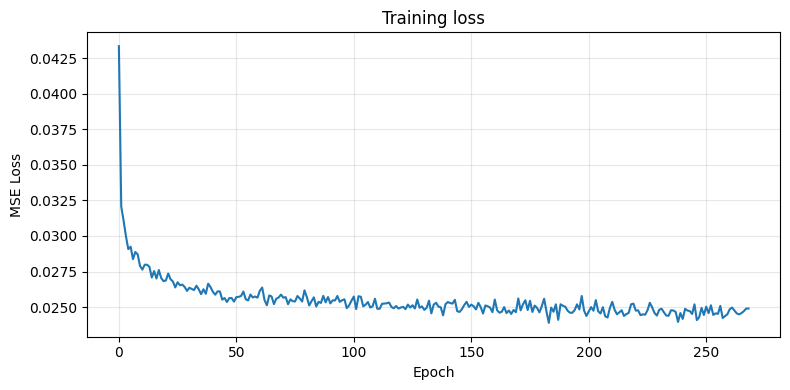

In [58]:
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Reverse Process : Génération d'images

On implémente l'algorithme de sampling DDPM (Algorithm 2 de Ho et al., 2020).

A chaque pas $t = T, T-1, \dots, 1$ :

$$\mathbf{x}_{t-1} = \frac{1}{\sqrt{\alpha_t}}\left(\mathbf{x}_t - \frac{\beta_t}{\sqrt{1 - \bar{\alpha}_t}}\,\boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t)\right) + \sigma_t\,\mathbf{z}$$

avec $\mathbf{z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$ pour $t > 1$ et $\mathbf{z} = \mathbf{0}$ pour $t = 1$.

In [59]:
@torch.no_grad()
def ddpm_sample(model, n_samples, img_size=IMG_SIZE, device=DEVICE):
    """
    Ancestral sampling DDPM : genere des images a partir de bruit pur.
    """
    model.eval()

    # Precalculs sur le device
    betas_d = betas.to(device)
    alphas_d = alphas.to(device)
    alphas_bar_d = alphas_bar.to(device)

    # 1. Partir de bruit pur x_T ~ N(0, I)
    x_t = torch.randn(n_samples, 1, img_size, img_size, device=device)

    # 2. boucle de t = T-1 a t = 0
    for t_val in tqdm(reversed(range(T)), total=T, desc="Sampling"):
        t_batch = torch.full((n_samples,), t_val, device=device, dtype=torch.long)

        # Predire le bruit
        eps_pred = model(x_t, t_batch)

        # Coefficients
        alpha_t = alphas_d[t_val]
        alpha_bar_t = alphas_bar_d[t_val]
        beta_t = betas_d[t_val]

        # Moyenne : mu = (1/sqrt(alpha_t)) * (x_t - beta_t / sqrt(1 - alpha_bar_t) * eps_pred)
        coef_eps = beta_t / torch.sqrt(1.0 - alpha_bar_t)
        mu = (x_t - coef_eps * eps_pred) / torch.sqrt(alpha_t)

        # Bruit : sigma_t * z (sauf au dernier pas)
        if t_val > 0:
            sigma_t = torch.sqrt(beta_t)
            z = torch.randn_like(x_t)
            x_t = mu + sigma_t * z
        else:
            x_t = mu

    return (x_t.clamp(-1, 1) + 1) / 2 

In [60]:
# --- Load le dernier checkpoint ---
checkpoint = torch.load("checkpoints_64/ddpm_epoch269.pt", map_location=DEVICE)
ema_model.load_state_dict(checkpoint["model_state_dict"])
ema_model.to(DEVICE)

UNet(
  (time_mlp): Sequential(
    (0): Linear(in_features=256, out_features=1024, bias=True)
    (1): SiLU()
    (2): Linear(in_features=1024, out_features=256, bias=True)
  )
  (conv1a): Conv2d(1, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv1b): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (time_proj1): Linear(in_features=256, out_features=128, bias=True)
  (norm1a): GroupNorm(8, 128, eps=1e-05, affine=True)
  (norm1b): GroupNorm(8, 128, eps=1e-05, affine=True)
  (conv2a): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2b): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (time_proj2): Linear(in_features=256, out_features=256, bias=True)
  (norm2a): GroupNorm(8, 256, eps=1e-05, affine=True)
  (norm2b): GroupNorm(8, 256, ep

Sampling: 100%|██████████| 1000/1000 [01:29<00:00, 11.23it/s]


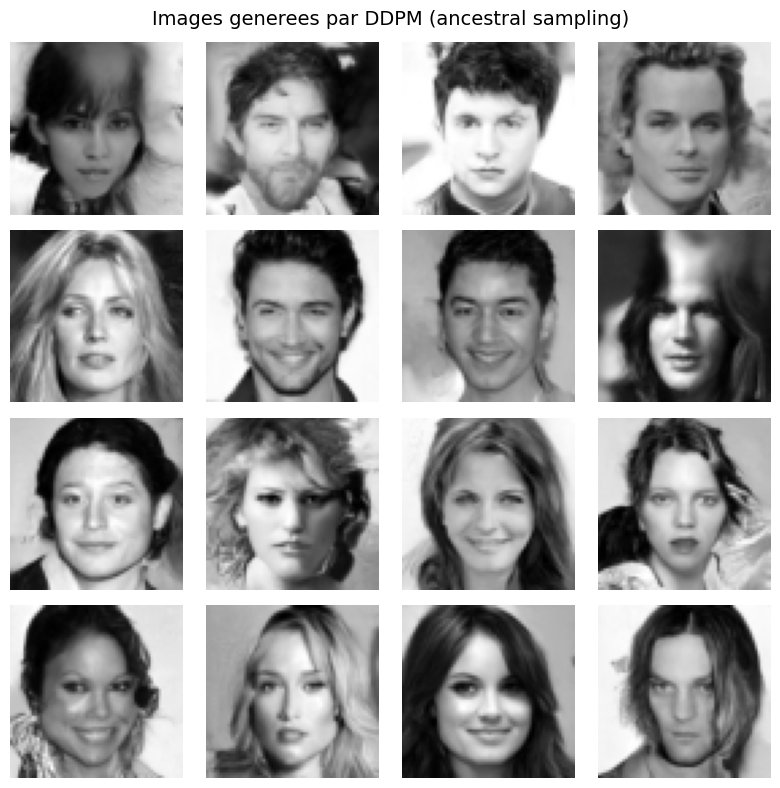

In [61]:
# --- Generer 16 images ---
generated = ddpm_sample(ema_model, n_samples=16) 

# --- Affichage en grille 4x4 ---
fig, axes = plt.subplots(4, 4, figsize=(8, 8)) 
for i, ax in enumerate(axes.flat):
    img = generated[i].cpu().squeeze(0).numpy()  
    ax.imshow(img, cmap='gray')     
    ax.axis("off")

fig.suptitle("Images generees par DDPM (ancestral sampling)", fontsize=14)
plt.tight_layout()
plt.show()

### Visualisation du processus de debruitage

On sauvegarde les images a differents timesteps pour voir comment le bruit se transforme progressivement en image.

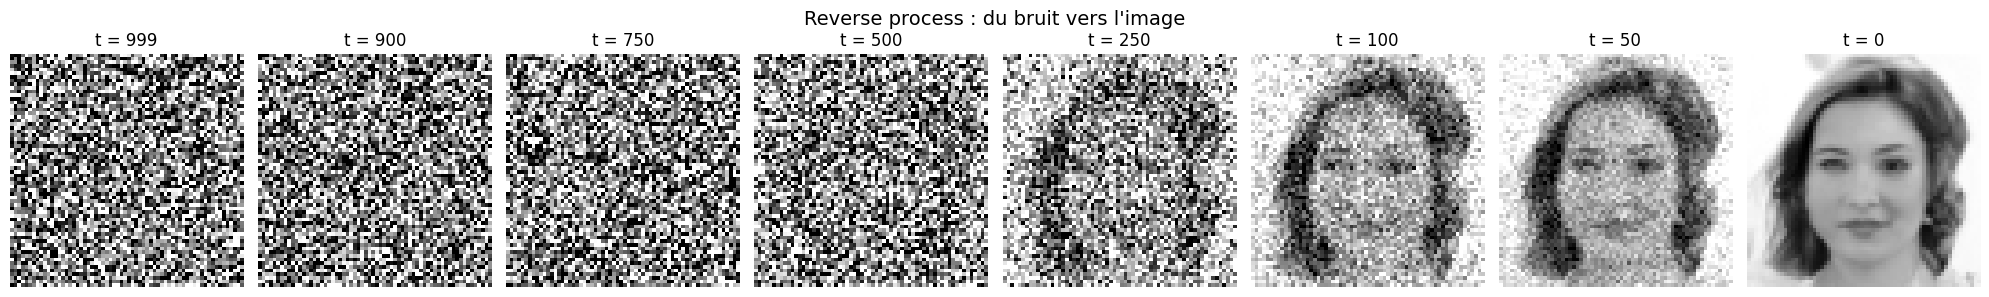

In [62]:
@torch.no_grad()
def ddpm_sample_with_snapshots(model, snapshot_steps, img_size=IMG_SIZE, device=DEVICE):
    """
    Genere UNE image et sauvegarde des snapshots aux timesteps donnes.
    """
    model.eval()

    betas_d = betas.to(device)
    alphas_d = alphas.to(device)
    alphas_bar_d = alphas_bar.to(device)

    x_t = torch.randn(1, 1, img_size, img_size, device=device)
    snapshots = {}

    for t_val in reversed(range(T)):
        if t_val in snapshot_steps:
            snapshots[t_val] = ((x_t[0].cpu().clamp(-1, 1) + 1) / 2)

        t_batch = torch.full((1,), t_val, device=device, dtype=torch.long)
        eps_pred = model(x_t, t_batch)

        alpha_t = alphas_d[t_val]
        alpha_bar_t = alphas_bar_d[t_val]
        beta_t = betas_d[t_val]

        coef_eps = beta_t / torch.sqrt(1.0 - alpha_bar_t)
        mu = (x_t - coef_eps * eps_pred) / torch.sqrt(alpha_t)

        if t_val > 0:
            x_t = mu + torch.sqrt(beta_t) * torch.randn_like(x_t)
        else:
            x_t = mu

    snapshots[0] = ((x_t[0].cpu().clamp(-1, 1) + 1) / 2)
    return snapshots


# --- Snapshots a afficher ---

for i in range(1):
    snapshot_steps = [999, 900, 750, 500, 250, 100, 50, 0]
    snapshots = ddpm_sample_with_snapshots(model, snapshot_steps)   
    fig, axes = plt.subplots(1, len(snapshot_steps), figsize=(2.5 * len(snapshot_steps), 3))

    for i, t_val in enumerate(snapshot_steps):
        img = snapshots[t_val].squeeze(0).numpy()
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f"t = {t_val}")
        axes[i].axis("off")

    fig.suptitle("Reverse process : du bruit vers l'image", fontsize=14)
    plt.tight_layout()
    plt.show()

---

# Partie III : Inpainting Conditionnel — Score Conditionnel avec Approximation Gaussienne

---

## 1. Du score marginal au score conditionnel

Jusqu'ici, l'échantillonnage DDPM utilisait le **score marginal** $\nabla_{x_t} \log p_t(x_t)$ (appris par $\epsilon_\theta$). Pour conditionner sur une observation $y$ (les pixels connus), on veut echantillonner $p_t(x_t | y)$. Avec la loi de Bayes :

$$\boxed{\nabla_{x_t} \log p_t(x_t | y) = \underbrace{\nabla_{x_t} \log p_t(x_t)}_{\text{score marginal (modele)}} + \underbrace{\nabla_{x_t} \log p_t(y | x_t)}_{\text{terme de vraisemblance}}}$$

Le premier terme est deja connu (c'est notre reseau $\epsilon_\theta$). Le probleme est le second : $p_t(y|x_t)$ est **intractable** car :

$$p_t(y | x_t) = \int p(y | x_0)\, p(x_0 | x_t)\, dx_0$$

et $p(x_0 | x_t)$ est une distribution complexe qu'on ne connait pas en forme fermee.

## 2. Approximation gaussienne de $p(x_0 | x_t)$

**L'idee principale** : on approche l'a posteriori $p(x_0 | x_t)$ par une gaussienne centree sur l'estimateur de Tweedie :

$$p(x_0 | x_t) \approx \mathcal{N}\!\Big(\hat{x}_0(x_t),\; r_t^2\, \mathbf{I}\Big)$$

ou :
- $\hat{x}_0 = \frac{x_t - \sqrt{1 - \bar\alpha_t}\,\epsilon_\theta(x_t, t)}{\sqrt{\bar\alpha_t}}$ est l'**estimateur de Tweedie**
- $r_t^2 = \frac{1 - \bar\alpha_t}{\bar\alpha_t}$ est la **variance residuelle** (grande quand $t$ est grand, petite quand $t \to 0$)

## 3. Application a l'inpainting

Pour l'inpainting, l'operateur d'observation est **lineaire** : $y = A\,x_0$ ou $A = \text{diag}(m)$ (le masque). Le bruit d'observation est $\sigma_y$.

Avec l'approximation gaussienne, la vraisemblance marginalisee devient tractable :

$$p_t(y | x_t) \approx \mathcal{N}\!\Big(A\,\hat{x}_0,\; r_t^2\, A A^\top + \sigma_y^2\, \mathbf{I}\Big)$$

En derivant le log par rapport a $x_t$ et en utilisant la chain rule $\frac{\partial \hat{x}_0}{\partial x_t} \approx \frac{1}{\sqrt{\bar\alpha_t}}\mathbf{I}$ (approximation), on obtient la **correction conditionnelle sur $\hat{x}_0$** :

$$\boxed{\hat{x}_0^{\text{cond}} = \hat{x}_0 + \frac{r_t^2 \cdot m}{r_t^2 \cdot m + \sigma_y^2} \odot \Big(y - m \odot \hat{x}_0\Big)}$$

**Interpretation** :
- Pour les pixels **connus** ($m_i = 1$) : le poids $\frac{r_t^2}{r_t^2 + \sigma_y^2}$ pousse $\hat{x}_0$ vers la valeur observee $y_i$
- Pour les pixels **inconnus** ($m_i = 0$) : le poids est $0$, pas de correction
- Quand $t$ est grand ($r_t^2 \gg \sigma_y^2$) : correction forte (on fait confiance a l'observation)
- Quand $t$ est petit ($r_t^2 \ll \sigma_y^2$) : correction faible (on fait confiance au modele)

## 4. Reverse

On injecte $\hat{x}_0^{\text{cond}}$ dans la **formule de l'a posteriori DDPM** $q(x_{t-1} | x_t, x_0)$ :

$$\mu_t^{\text{cond}} = \frac{\sqrt{\bar\alpha_{t-1}}\,\beta_t}{1 - \bar\alpha_t}\,\hat{x}_0^{\text{cond}} + \frac{\sqrt{\alpha_t}\,(1 - \bar\alpha_{t-1})}{1 - \bar\alpha_t}\,x_t$$

$$x_{t-1} = \mu_t^{\text{cond}} + \tilde\beta_t\, z, \quad z \sim \mathcal{N}(0, I), \quad \tilde\beta_t = \frac{(1 - \bar\alpha_{t-1})\,\beta_t}{1 - \bar\alpha_t}$$

Image originale : 2316 x 3088
x_face shape: torch.Size([1, 1, 64, 64]), min=-0.84, max=1.00


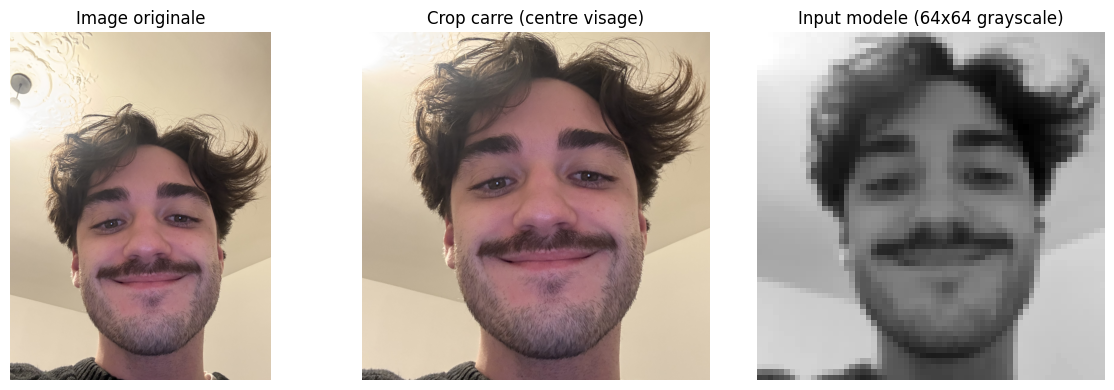

In [63]:
# --- Charger et pretraiter votre_image.jpeg ---
img_pil = Image.open("votre_image.jpeg")
w, h = img_pil.size
print(f"Image originale : {w} x {h}")

# Crop carre centre sur le visage
# Biais vers le haut (0.25) car le visage est dans la partie superieure d'un selfie
crop_size = min(w, h)
left = (w - crop_size) // 2
top = int((h - crop_size)*0.9 )
top = max(0, top)
right = left + crop_size
bottom = min(h, top + crop_size)

img_cropped = img_pil.crop((left, top, right, bottom))

# Resize 64x64 + grayscale + normalisation [-1, 1] (meme preprocessing que le training)
transform_face = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.CenterCrop(IMG_SIZE),
    transforms.Grayscale(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

x_face = transform_face(img_cropped).unsqueeze(0)  # (1, 1, 64, 64)
print(f"x_face shape: {x_face.shape}, min={x_face.min():.2f}, max={x_face.max():.2f}")

# --- Affichage ---
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img_pil)
axes[0].set_title("Image originale")
axes[0].axis("off")

axes[1].imshow(img_cropped)
axes[1].set_title("Crop carre (centre visage)")
axes[1].axis("off")

axes[2].imshow((x_face[0, 0].numpy() + 1) / 2, cmap='gray')
axes[2].set_title(f"Input modele ({IMG_SIZE}x{IMG_SIZE} grayscale)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

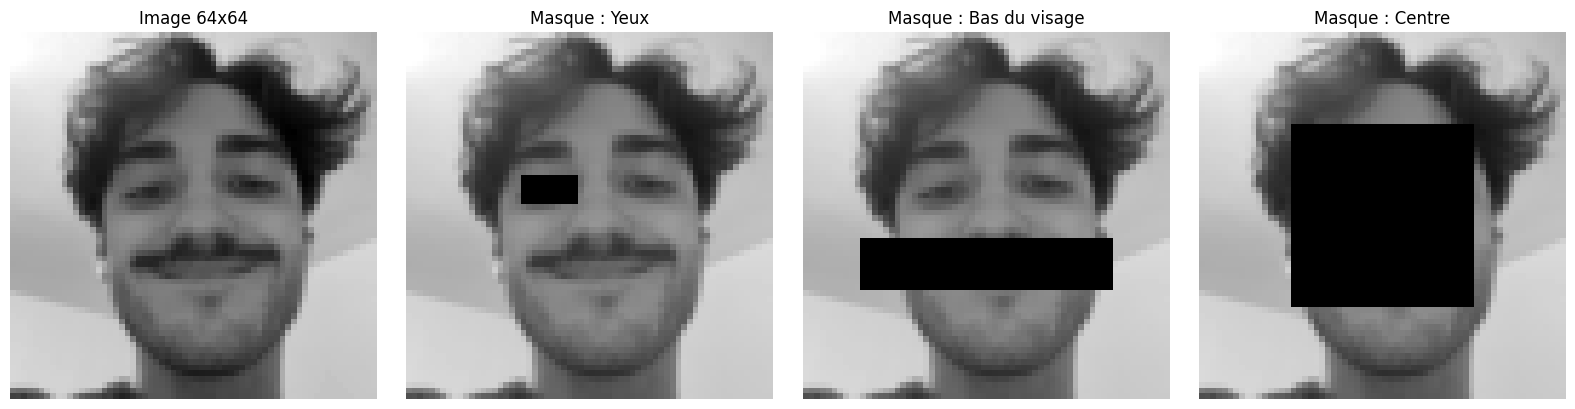

In [64]:
# === Masques d'inpainting ===
# mask = 1 : pixel connu (on garde), mask = 0 : pixel a reconstruire

def create_mask_eyes(h=64, w=64):
    """Masque la zone des yeux"""
    mask = torch.ones(1, 1, h, w)
    mask[:, :, 25:30, 20:30] = 0
    return mask

def create_mask_lower(h=64, w=64):
    """Masque le bas du visage (bouche + menton)"""
    mask = torch.ones(1, 1, h, w)
    mask[:, :, 36:45, 10:54] = 0
    return mask

def create_mask_center(h=64, w=64):
    """Masque le centre du visage"""
    mask = torch.ones(1, 1, h, w)
    mask[:, :, 16:48, 16:48] = 0
    return mask

# --- Visualisation des masques sur l'image ---
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
img_display = (x_face[0, 0].numpy() + 1) / 2

axes[0].imshow(img_display, cmap='gray')
axes[0].set_title("Image 64x64")
axes[0].axis("off")

for i, (name, mask_fn) in enumerate([
    ("Yeux", create_mask_eyes),
    ("Bas du visage", create_mask_lower),
    ("Centre", create_mask_center),
]):
    m = mask_fn()
    masked_img = img_display * m[0, 0].numpy()
    axes[i + 1].imshow(masked_img, cmap='gray')
    axes[i + 1].set_title(f"Masque : {name}")
    axes[i + 1].axis("off")

plt.tight_layout()
plt.show()

# === Inpainting par score conditionnel (approximation gaussienne, style PiGDM) ===

@torch.no_grad()
def inpaint_conditional_score(model, x_0, mask, sigma_y=0.1, r_t_scale=1.0, device=DEVICE):
    """
    Inpainting par score conditionnel avec approximation gaussienne.

    Score conditionnel (Bayes) :
        nabla log p(x_t | y) = nabla log p_t(x_t) + nabla log p_t(y | x_t)

    Approximation gaussienne :
        p(x_0 | x_t) ~ N(x0_hat, r_t^2 I)   avec x0_hat = Tweedie, r_t^2 = (1-abar_t)/abar_t

    Pour inpainting (operateur lineaire A = diag(m)) :
        x0_hat_cond = x0_hat + r_t^2 * m / (r_t^2 * m + sigma_y^2) * (y - m * x0_hat)

    Puis reverse step DDPM avec x0_hat_cond au lieu de x0_hat.

    Args:
        model: reseau epsilon_theta entraine (score marginal)
        x_0: image originale (1, 1, 64, 64) normalisee [-1, 1]
        mask: masque binaire (1, 1, 64, 64) : 1 = connu, 0 = a reconstruire
        sigma_y: ecart-type du bruit d'observation (regularisation)
        r_t_scale: facteur multiplicatif sur r_t^2 (default 1.0, >1 = plus de correction, <1 = moins)\n
    """
    model.eval()
    betas_d = betas.to(device)
    alphas_d = alphas.to(device)
    alphas_bar_d = alphas_bar.to(device)

    x_0_d = x_0.to(device)
    mask_d = mask.to(device)
    y = mask_d * x_0_d  # observation : pixels connus

    # Partir de bruit pur
    x_t = torch.randn(1, 1, IMG_SIZE, IMG_SIZE, device=device)

    for t_val in tqdm(reversed(range(T)), total=T, desc="Inpainting (score cond.)"):
        t_batch = torch.full((1,), t_val, device=device, dtype=torch.long)

        alpha_bar_t = alphas_bar_d[t_val]
        alpha_t = alphas_d[t_val]
        beta_t = betas_d[t_val]

        #1. Score marginal : prediction du bruit
        eps_pred = model(x_t, t_batch)

        #2. Estimateur de Tweedie : x0_hat
        x0_hat = (x_t - torch.sqrt(1 - alpha_bar_t) * eps_pred) / torch.sqrt(alpha_bar_t)

        #3. Correction conditionnelle (approximation gaussienne)
        # Variance residuelle : r_t^2 = r_t_scale * (1 - alpha_bar_t) / alpha_bar_t
        r_t_sq = r_t_scale * (1 - alpha_bar_t) / alpha_bar_t

        # Poids de correction : r_t^2 * m / (r_t^2 * m + sigma_y^2)
        weight = (r_t_sq * mask_d) / (r_t_sq * mask_d + sigma_y ** 2)

        # x0_hat corrige par la vraisemblance
        x0_hat_cond = x0_hat + weight * (y - mask_d * x0_hat)

        #4. Reverse step DDPM avec x0_hat_cond
        if t_val > 0:
            alpha_bar_prev = alphas_bar_d[t_val - 1]

            # Moyenne de l'a posteriori q(x_{t-1} | x_t, x0_hat_cond)
            coef_x0 = torch.sqrt(alpha_bar_prev) * beta_t / (1 - alpha_bar_t)
            coef_xt = torch.sqrt(alpha_t) * (1 - alpha_bar_prev) / (1 - alpha_bar_t)
            mu = coef_x0 * x0_hat_cond + coef_xt * x_t

            # Variance de l'a posteriori
            beta_tilde = (1 - alpha_bar_prev) * beta_t / (1 - alpha_bar_t)
            sigma_t = torch.sqrt(beta_tilde)

            z = torch.randn_like(x_t)
            x_t = mu + sigma_t * z
        else:
            x_t = x0_hat_cond

    return (x_t.clamp(-1, 1) + 1) / 2

In [69]:
r_t_scale = 0.9
sigma_y = 0.05

In [ ]:
# --- Lancer l'inpainting avec les 3 masques ---
masks = {
    "Yeux masques": create_mask_eyes(),
    "Bas du visage masque": create_mask_lower(),
    "Centre masque": create_mask_center(),
}

fig, axes = plt.subplots(len(masks), 4, figsize=(16, 4 * len(masks)))

for row, (name, mask) in enumerate(masks.items()):
    # Image originale
    axes[row, 0].imshow((x_face[0, 0].numpy() + 1) / 2, cmap='gray')
    axes[row, 0].set_title("Original")
    axes[row, 0].axis("off")

    # Masque
    axes[row, 1].imshow(mask[0, 0].numpy(), cmap='gray', vmin=0, vmax=1)
    axes[row, 1].set_title("Masque")
    axes[row, 1].axis("off")

    # Image masquee (pixels inconnus en noir)
    img_masked = (x_face[0, 0].numpy() + 1) / 2 * mask[0, 0].numpy()
    axes[row, 2].imshow(img_masked, cmap='gray')
    axes[row, 2].set_title("Image masquee")
    axes[row, 2].axis("off")

    # Inpainting par score conditionnel
    result = inpaint_conditional_score(model, x_face, mask, sigma_y, r_t_scale)
    axes[row, 3].imshow(result[0, 0].cpu().numpy(), cmap='gray')
    axes[row, 3].set_title(f"Reconstruction ({name})")
    axes[row, 3].axis("off")

fig.suptitle("Inpainting par score conditionnel (approx. gaussienne)", fontsize=16)
plt.tight_layout()
plt.show()

: 